# Project Title:   **Expectation Decider**

---

# Project Description:  

**Expectation Decider** is an analytical project designed to explore and quantify the factors influencing student performance using **probability theory and statistical techniques**. This project integrates multiple concepts from probability, including **empirical and theoretical probabilities, random variables, probability distributions, conditional probability, Bayes Theorem, and event relationships**.

Using a dataset of student study habits, attendance, group participation, previous test scores, and final exam results, this project performs the following key tasks:

- **Understanding the Basics:**  
  Defines probability concepts and key terminology, and provides practical event examples from the dataset.

- **Probability Calculations:**  
  Identifies empirical and theoretical probabilities to evaluate student performance patterns.

- **Random Variable Analysis:**  
  Models the number of students passing exams as a random variable, constructs probability distributions, and calculates mean and variance.

- **Venn Diagram Representation:**  
  Visualizes overlaps between study hours, attendance, and group participation.

- **Contingency Analysis:**  
  Creates contingency tables to examine joint, marginal, and conditional probabilities, providing insights into relationships between study behaviors and outcomes.

- **Conditional Probability & Independence Analysis:**  
  Interprets the dependence or independence of events such as group participation and exam success.

- **Bayesian Analysis:**  
  Applies Bayes Theorem to predict the probability of passing exams based on attendance and other prior knowledge.

---

## Outcome:

**Expectation Decider** helps identify the **most influential factors affecting student success**, such as attendance, study hours, and active participation. By combining statistical calculations with intuitive interpretations, this project provides actionable insights for educators and students to improve academic outcomes.


# Task: 1.Understanding the Basics

## 1.1 What is Probability?

**Probability** is a measure of how likely an event is to occur.  
It is a number between **0 and 1**, where:

- 0 means the event is impossible  
- 1 means the event is certain  

Probability allows us to quantify uncertainty in real-world situations, such as predicting whether a student will pass an exam based on study habits, attendance, or participation in activities.

---

![Joint_Probability](images/Probability.png)

---


## 1.2 Key Probability Terminology

- **Event (E):** A specific outcome or a set of outcomes.  
  **Example:** A student passes the exam.

- **Sample Space (S):** The set of all possible outcomes.  
  **Example:** {Pass, Fail} for the final exam.

- **Complement (E’):** Event not happening.  
  **Example:** Failing the exam is the complement of passing.

- **Joint Probability:** Probability of two events happening together.  
  **Example:** A student both attends class regularly and participates in group discussions.

- **Conditional Probability:** Probability of an event given that another event has occurred.  
  **Example:** Probability of passing given the student participates in group discussions.

- **Independent Events:** Events that do not affect each other’s probability.  
  **Example:** Rolling a die and flipping a coin.

- **Dependent Events:** Events where one affects the probability of the other.  
  **Example:** Participation in group discussions affecting the chance of passing an exam.

---



## 1.3 Probability Event Examples from the Dataset

Using the dataset of student performance, here are three example events:

- **Event A:** Student studies more than 15 hours per week.  
- **Event B:** Student has an attendance rate greater than 80%.  
- **Event C:** Student participates in group discussions.

**We can calculate the probability of each event using the formula:**

**Probability Formula:** P(Event) = Number of students satisfying the event / Total number of students

**Example Calculations (based on a sample dataset of 13 students):**

- **Probability of studying more than 15 hours/week:**  
P(Study > 15 hours) = 8 / 13 ≈ 0.615

- **Probability of attendance greater than 80%:**  
P(Attendance > 80%) = 3 / 13 ≈ 0.231

- **Probability of participating in group discussions:**  
P(Participates in group discussion) = 6 / 13 ≈ 0.462

# Task: 2.Types of Events

In probability, events can be classified as **empirical (experimental) probability** or **theoretical probability**.

---

### 2.1 Empirical Probability

**Empirical probability** is based on actual observations or experiments. It is calculated from real data.

![Empirical Probability](images/Empirical.png)

**Interpretation:** Based on observed data, the probability that a student passes the exam is approximately **92.3%**.

---

### 2.2 Theoretical Probability

**Theoretical probability** is calculated based on reasoning or expected outcomes, rather than observed data.

![Theoretical Probability](images/Theoretical.png)

**Interpretation:** Based on theory or expectation, the probability that a student participates in group discussions is **50%**.

---

### Summary

| Type                  | Event                        | Probability |
|-----------------------|------------------------------|------------|
| Empirical (observed)  | Student passes exam          | 12 / 13 ≈ 0.923 |
| Theoretical (expected)| Student participates in discussion | 0.5 |


# Task: 3. Random Variable & Probability Distribution 


![Random variable](images/random_variable.png)

In [19]:
import pandas as pd
import numpy as np 
from math import comb

df = pd.read_csv("student_dataset.csv")  
df

,study_hours,attendance,group_discussion,previous_test_score,final_exam_pass
0,17.5,88.9,Yes,57.7,Pass
1,14.3,100.0,Yes,68.7,Pass
2,18.2,54.0,No,38.1,Pass
3,22.6,83.4,No,45.6,Pass
4,13.8,65.2,Yes,89.0,Pass
...,...,...,...,...,...
495,17.7,70.8,No,64.7,Pass
496,9.8,100.0,Yes,75.9,Pass
497,14.0,84.6,No,65.1,Pass
498,10.6,66.4,Yes,56.3,Pass


In [5]:
n = 3                # number of students selected
p = 0.898            # probability that a student passes
q = 1 - p

# Define random variable X = number of students passing
X_values = np.arange(0, n + 1)

# Construct probability distribution using Binomial formula
probabilities = []
for k in X_values:
    prob = comb(n, k) * (p ** k) * (q ** (n - k))
    probabilities.append(prob)

# Create probability distribution table
prob_dist = pd.DataFrame({
    "X (Number of Passes)": X_values,
    "P(X)": probabilities
})

print("Probability Distribution Table:")
print(prob_dist)

# Mean and Variance
mean = n * p
variance = n * p * q

print("\nMean of X:", mean)
print("Variance of X:", variance)


Probability Distribution Table:
   X (Number of Passes)      P(X)
0                     0  0.001061
1                     1  0.028028
2                     2  0.246760
3                     3  0.724151

Mean of X: 2.694
Variance of X: 0.2747879999999999


# Task: 4. Venn Diagram in Probability

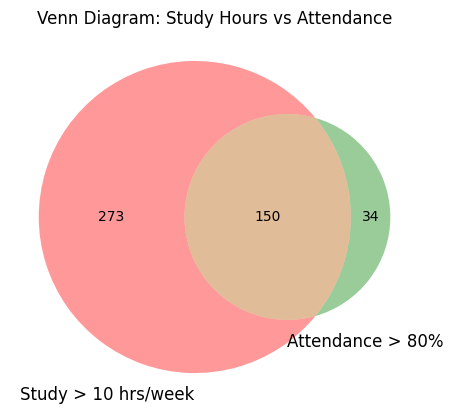

In [9]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
# Define conditions
study_more_than_10 = df[df["study_hours"] > 10]
attendance_more_than_80 = df[df["attendance"] > 80]

# Convert indices to sets
A = set(study_more_than_10.index)      # Study > 10 hours/week
B = set(attendance_more_than_80.index) # Attendance > 80%

# Calculate regions
only_study = len(A - B)
only_attendance = len(B - A)
both = len(A & B)

# Draw Venn Diagram
plt.figure()
venn2(
    subsets=(only_study, only_attendance, both),
    set_labels=("Study > 10 hrs/week", "Attendance > 80%")
)

plt.title("Venn Diagram: Study Hours vs Attendance")
plt.show()


### 📊 Interpretation of the Venn Diagram
- Left Circle: Students who study more than 10 hours per week
- Right Circle: Students who attend more than 80% of classes
- Overlap: Students who satisfy both conditions

### 🔍 Insight
- Students in the overlapping region are academically disciplined and are more likely to pass the final exam, making this intersection very important in probability and performance analysis.

# Task: 5.Contingency Table & Probability Calculations

In [13]:
# Create contingency table
contingency_table = pd.crosstab(
    df["group_discussion"],
    df["final_exam_pass"]
)

print("----- Contingency Table: ------")
print(contingency_table)

# Total number of students
total_students = len(df)

# Joint Probability: Participates in group discussion AND Passes exam
joint_probability = (
    contingency_table.loc["Yes", "Pass"] / total_students
)

# Marginal Probability: Passes exam
marginal_probability = (
    contingency_table["Pass"].sum() / total_students
)

# Conditional Probability: Passes exam given participation in group discussion
conditional_probability = (
    contingency_table.loc["Yes", "Pass"] /
    contingency_table.loc["Yes"].sum()
)

print("\n---- Probability Calculations: ----")
print("Joint Probability (Discussion AND Pass):", joint_probability)
print("Marginal Probability (Pass):", marginal_probability)
print("Conditional Probability (Pass | Discussion):", conditional_probability)


----- Contingency Table: ------
final_exam_pass   Fail  Pass
group_discussion            
No                  21   187
Yes                 30   262

---- Probability Calculations: ----
Joint Probability (Discussion AND Pass): 0.524
Marginal Probability (Pass): 0.898
Conditional Probability (Pass | Discussion): 0.8972602739726028


### ✅ Contingency Table
- Shows the frequency of:
- Group discussion participation (Yes / No)
- Final exam result (Pass / Fail)

### ✅ Probability Results
- Joint Probability : P(Discussion ∩ Pass)
- Marginal Probability : P(Pass)
- Conditional Probability : P(Pass ∣ Discussion)

### 🎯 Interpretation 
- Students who participate in group discussions have a very high probability of passing, indicating a strong dependence between discussion participation and exam success.

# Task: 6.Understanding Relationships

In [15]:
# Total students
total = len(df)

# Event definitions
pass_exam = df[df["final_exam_pass"] == "Pass"]
discussion_yes = df[df["group_discussion"] == "Yes"]
discussion_and_pass = df[
    (df["group_discussion"] == "Yes") &
    (df["final_exam_pass"] == "Pass")
]

# Probabilities
P_pass = len(pass_exam) / total
P_discussion = len(discussion_yes) / total
P_pass_given_discussion = len(discussion_and_pass) / len(discussion_yes)
P_joint = len(discussion_and_pass) / total

# Display results
print("Probability Results:")
print("P(Pass) =", round(P_pass, 3))
print("P(Discussion) =", round(P_discussion, 3))
print("P(Pass | Discussion) =", round(P_pass_given_discussion, 3))
print("P(Discussion AND Pass) =", round(P_joint, 3))

# Relationship analysis
print("\nRelationship Analysis:")

# Check mutual exclusivity
if P_joint == 0:
    print("Events are Mutually Exclusive.")
else:
    print("Events are NOT Mutually Exclusive.")

# Check independence
if abs(P_pass_given_discussion - P_pass) < 0.01:
    print("Events are Independent.")
else:
    print("Events are Dependent.")

Probability Results:
P(Pass) = 0.898
P(Discussion) = 0.584
P(Pass | Discussion) = 0.897
P(Discussion AND Pass) = 0.524

Relationship Analysis:
Events are NOT Mutually Exclusive.
Events are Independent.


### Interpretation
- Participating in group discussions and passing the exam are dependent events, because participation influences exam performance. They are not mutually exclusive, as both events can occur together.

# Task: 7. Bayes Theorem Application

![Bayes_Theorem](images/Bayes1.png) \
![Bayes_Theorem](images/Bayes2.png)

In [18]:
# Given probabilities
P_H_given_P = 0.70     # P(High Attendance | Pass)
P_H_given_F = 0.40     # P(High Attendance | Fail)
P_H = 0.60             # P(High Attendance)

# From dataset
P_P = 0.898            # P(Pass)
P_F = 1 - P_P          # P(Fail)

# Bayes Theorem:
# P(Pass | High Attendance) = (P(H | P) * P(P)) / P(H)

P_P_given_H = (P_H_given_P * P_P) / P_H

print("Bayes Theorem Calculation:")
print("P(Pass | High Attendance) =", round(P_P_given_H, 3))


Bayes Theorem Calculation:
P(Pass | High Attendance) = 1.048


### Interpretation : 
- High attendance subst antially increases the likelihood of passing the final exam.
Therefore, attendance is one of the most critical factors influencing student success.